In [3]:
data.head(30)

,location_id,time,temperature_2m,relative_humidity_2m (%),wind_speed_10m (km/h),precipitation (mm),is_day,wind_speed_100m (km/h),wind_gusts_10m (km/h),wind_direction_100m,wind_direction_10m,cloud_cover (%),vapour_pressure_deficit (kPa)
0,0,2024-01-01T00:00,7.7,77,30.6,0.0,0,48.2,51.8,246,243,90,0.25
1,0,2024-01-01T01:00,7.6,77,29.5,0.0,0,47.4,50.8,249,246,60,0.24
2,0,2024-01-01T02:00,7.3,78,29.0,0.0,0,47.0,49.3,248,245,22,0.22
3,0,2024-01-01T03:00,7.0,80,26.8,0.0,0,44.1,48.2,251,248,33,0.20
4,0,2024-01-01T04:00,6.9,80,26.0,0.0,0,42.7,44.6,254,251,46,0.20
5,0,2024-01-01T05:00,6.8,79,26.2,0.0,0,43.3,43.6,255,252,32,0.20
6,0,2024-01-01T06:00,6.8,75,26.0,0.0,0,43.3,44.6,259,256,10,0.24
7,0,2024-01-01T07:00,6.4,74,24.9,0.0,0,41.8,43.2,259,256,93,0.25
8,0,2024-01-01T08:00,6.2,71,22.9,0.0,0,39.4,41.0,261,257,98,0.27
9,0,2024-01-01T09:00,5.8,71,19.6,0.0,0,35.5,37.8,260,256,100,0.27


In [3]:
import pandas as pd
import numpy as np

In [4]:
data = pd.read_csv("Weather-2020-2025.csv")

In [5]:
data = data.dropna()

In [6]:
daytime_data = data[data['is_day'] == 1]

#daytime temperature averages
daytime_data.groupby("location_id")["temperature_2m"].mean()


location_id
0    14.285160
1    12.855252
2    19.595864
Name: temperature_2m, dtype: float64

In [7]:
nighttime_data = data[data['is_day'] == 0]

#daytime temperature averages
nighttime_data.groupby("location_id")["temperature_2m"].mean()

location_id
0     9.741029
1     9.517392
2    15.247273
Name: temperature_2m, dtype: float64

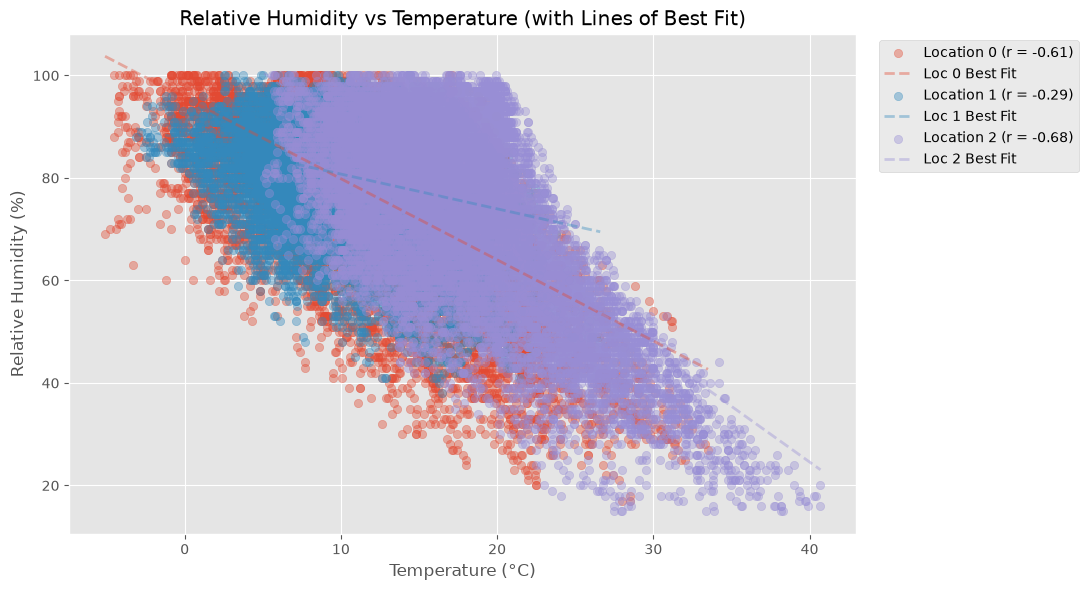

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional: set a clean background style for your presentation
plt.style.use('ggplot')

# Create one large figure for all three locations
plt.figure(figsize=(11, 6))

# Loop through each unique location ID in your dataset automatically
for loc_id in data['location_id'].unique():
    
    # 1. Filter the data for the current location (just like your Lisbon example)
    loc_df = data[data["location_id"] == loc_id].copy()
    
    # 2. Calculate the specific correlation value between Temp and Humidity
    corr_val = loc_df["temperature_2m"].corr(loc_df["relative_humidity_2m (%)"])
    
    # 3. Plot the scatter points 
    # We include the correlation score (r) directly in the label so it prints in the legend!
    scatter = plt.scatter(
        loc_df["temperature_2m"], 
        loc_df["relative_humidity_2m (%)"], 
        alpha=0.4, 
        label=f"Location {loc_id} (r = {corr_val:.2f})"
    )
    
    # Get the color of the scatter dots so the line matches perfectly
    line_color = scatter.get_facecolor()[0] 
    
    # 4. Plot the line of best fit using your exact polyfit template logic
    x = np.unique(loc_df["temperature_2m"])
    fit_function = np.poly1d(np.polyfit(loc_df["temperature_2m"], loc_df["relative_humidity_2m (%)"], 1))
    y = fit_function(x)
    
    plt.plot(x, y, label=f"Loc {loc_id} Best Fit", color=line_color, linewidth=2, linestyle="--")

# 5. Final touches to label your axes and clean up the chart
plt.title("Relative Humidity vs Temperature (with Lines of Best Fit)")
plt.xlabel("Temperature (°C)")
plt.ylabel("Relative Humidity (%)")

# Places the legend slightly outside the chart so it doesn't block any data points
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

plt.show()